# Task 5

# Objective : Analyze business performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## Summary Statistics

In [4]:
print(df['Sales'].describe())

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64


## Monthly Sales Trend

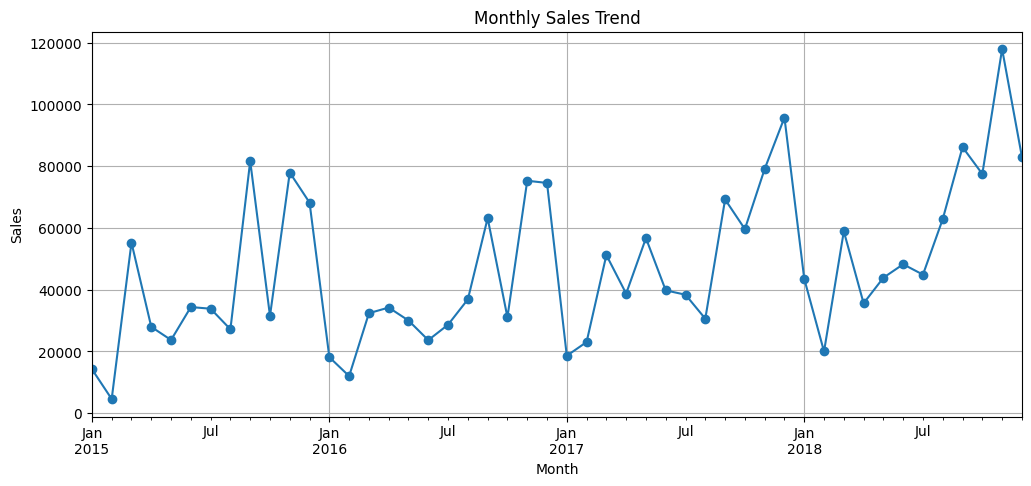

In [13]:
df['Order Date']=pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

monthly_sale = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sale.plot(kind='line',marker='o',figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

This shows business growth over time and identities peak and low sales months.

## Top 10 selling Products

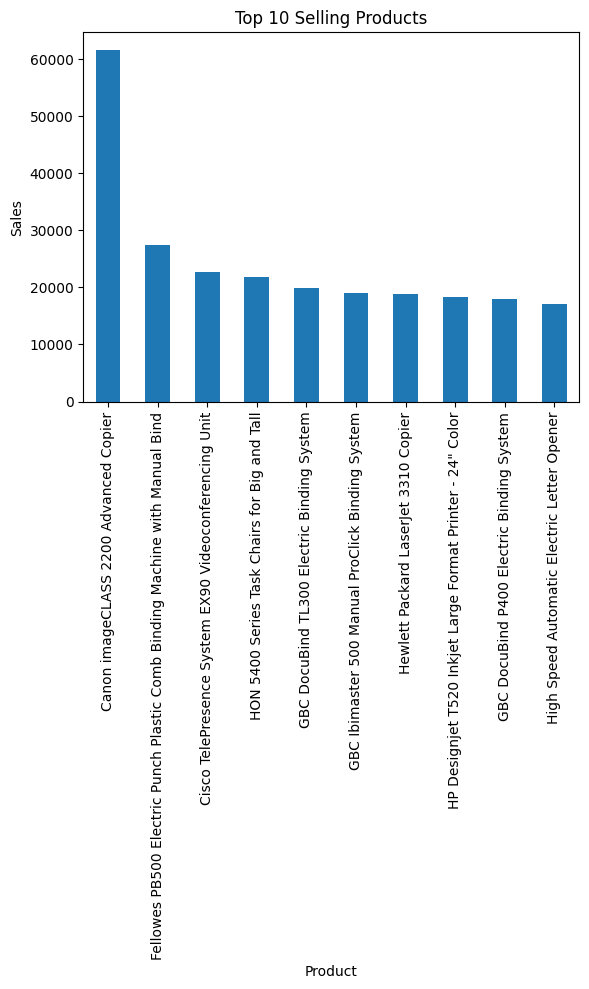

In [14]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

This shows which products were sale most.

## Sales by category

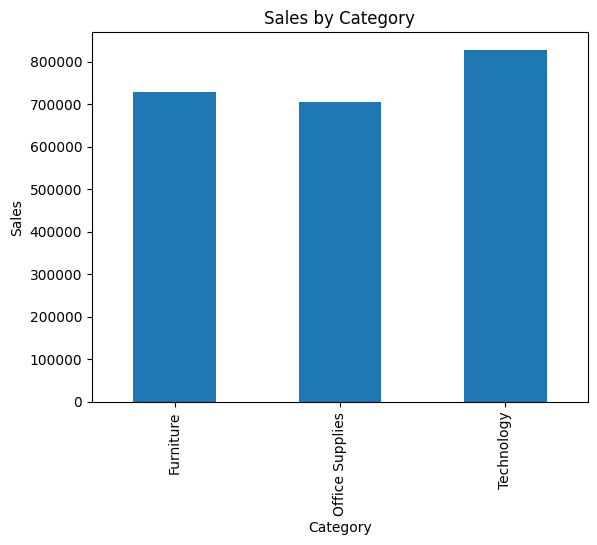

In [15]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Here it compares sales of categories (Furniture, Office Supplies, Technology).

## Sales by region

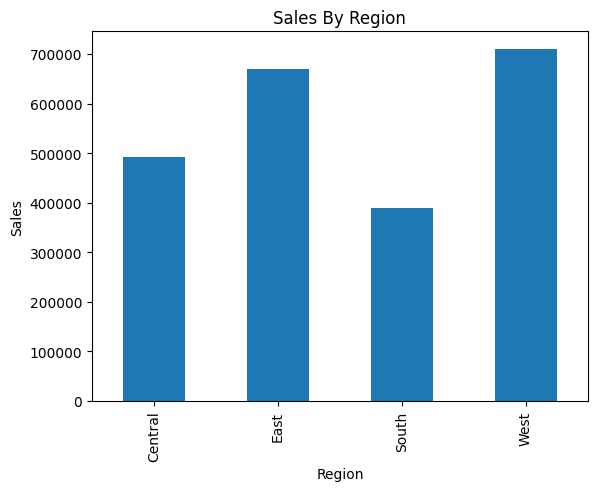

In [16]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')

plt.title("Sales By Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

It shows the strongest market region.

## Top 10 States by Sales

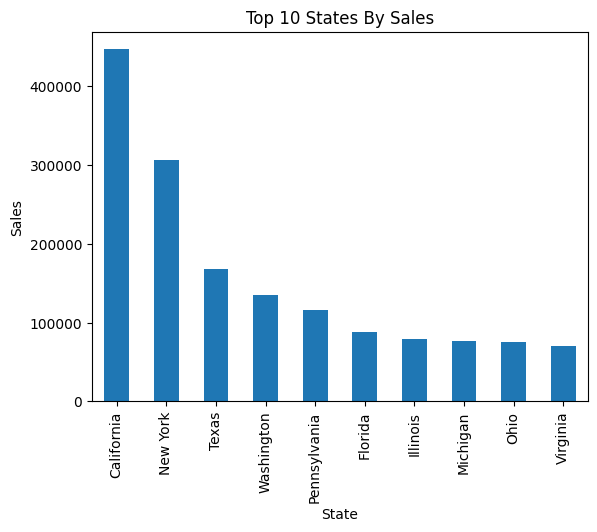

In [18]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')

plt.title("Top 10 States By Sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.show()

It shows that which states contribute most in sales.

## Correlation Analysis

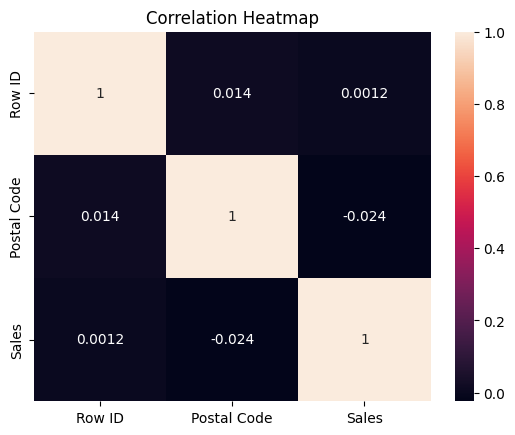

In [19]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),annot=True)

plt.title("Correlation Heatmap")
plt.show()